# YouTube Trending Videos Data Cleaning

This notebook focuses on cleaning the YouTube Trending Videos dataset (US region).
The objective is to identify and handle missing values, duplicate records, inconsistent
data formats, and outliers to ensure the dataset is accurate, consistent, and reliable
for further analysis.

In [1]:
import pandas as pd

df = pd.read_csv("USvideos.csv")
df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...


## Dataset Structure and Basic Information

Understanding the structure of the dataset is important before cleaning.
In this section, the number of rows, columns, data types, and basic statistics
are examined to identify potential data quality issues.

In [2]:
df.shape

(40949, 16)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                40949 non-null  object
 1   trending_date           40949 non-null  object
 2   title                   40949 non-null  object
 3   channel_title           40949 non-null  object
 4   category_id             40949 non-null  int64 
 5   publish_time            40949 non-null  object
 6   tags                    40949 non-null  object
 7   views                   40949 non-null  int64 
 8   likes                   40949 non-null  int64 
 9   dislikes                40949 non-null  int64 
 10  comment_count           40949 non-null  int64 
 11  thumbnail_link          40949 non-null  object
 12  comments_disabled       40949 non-null  bool  
 13  ratings_disabled        40949 non-null  bool  
 14  video_error_or_removed  40949 non-null  bool  
 15  de

In [4]:
df.describe()

,category_id,views,likes,dislikes,comment_count
count,40949.000000,4.094900e+04,4.094900e+04,4.094900e+04,4.094900e+04
mean,19.972429,2.360785e+06,7.426670e+04,3.711401e+03,8.446804e+03
std,7.568327,7.394114e+06,2.288853e+05,2.902971e+04,3.743049e+04
min,1.000000,5.490000e+02,0.000000e+00,0.000000e+00,0.000000e+00
25%,17.000000,2.423290e+05,5.424000e+03,2.020000e+02,6.140000e+02
50%,24.000000,6.818610e+05,1.809100e+04,6.310000e+02,1.856000e+03
75%,25.000000,1.823157e+06,5.541700e+04,1.938000e+03,5.755000e+03
max,43.000000,2.252119e+08,5.613827e+06,1.674420e+06,1.361580e+06


## Missing Values and Data Integrity Check

Checking for missing values is an important step in data cleaning.
Missing or incomplete data can affect the reliability of analysis results,
so identifying such issues early helps in making informed cleaning decisions.

In [5]:
df.isnull().sum()

video_id                    0
trending_date               0
title                       0
channel_title               0
category_id                 0
publish_time                0
tags                        0
views                       0
likes                       0
dislikes                    0
comment_count               0
thumbnail_link              0
comments_disabled           0
ratings_disabled            0
video_error_or_removed      0
description               570
dtype: int64

In [6]:
(df.isnull().sum() / len(df)) * 100

video_id                  0.000000
trending_date             0.000000
title                     0.000000
channel_title             0.000000
category_id               0.000000
publish_time              0.000000
tags                      0.000000
views                     0.000000
likes                     0.000000
dislikes                  0.000000
comment_count             0.000000
thumbnail_link            0.000000
comments_disabled         0.000000
ratings_disabled          0.000000
video_error_or_removed    0.000000
description               1.391975
dtype: float64

In [7]:
df.isnull().any()

video_id                  False
trending_date             False
title                     False
channel_title             False
category_id               False
publish_time              False
tags                      False
views                     False
likes                     False
dislikes                  False
comment_count             False
thumbnail_link            False
comments_disabled         False
ratings_disabled          False
video_error_or_removed    False
description                True
dtype: bool

## Handling Missing Values

After identifying missing values in the dataset, appropriate methods are
applied to handle them. Proper treatment of missing data helps improve
data quality and ensures reliable analysis.

In [8]:
# Check missing values again
df.isnull().sum()

video_id                    0
trending_date               0
title                       0
channel_title               0
category_id                 0
publish_time                0
tags                        0
views                       0
likes                       0
dislikes                    0
comment_count               0
thumbnail_link              0
comments_disabled           0
ratings_disabled            0
video_error_or_removed      0
description               570
dtype: int64

In [9]:
# Drop rows with missing values
df.dropna(inplace=True)

In [10]:
# Verify missing values after cleaning
df.isnull().sum()

video_id                  0
trending_date             0
title                     0
channel_title             0
category_id               0
publish_time              0
tags                      0
views                     0
likes                     0
dislikes                  0
comment_count             0
thumbnail_link            0
comments_disabled         0
ratings_disabled          0
video_error_or_removed    0
description               0
dtype: int64

## Duplicate Record Removal

Duplicate records can lead to biased results and incorrect conclusions.
In this step, the dataset is checked for duplicate entries and cleaned
to ensure that each record is unique.

In [11]:
df.duplicated().sum()

np.int64(47)

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.duplicated().sum()

np.int64(0)

## Data Standardization and Formatting

To maintain consistency across the dataset, text-based columns are
standardized and formatting issues are corrected. Standardization
helps improve data quality and avoids inconsistencies during analysis.

In [14]:
# Convert text columns to consistent format
df['title'] = df['title'].str.strip()
df['channel_title'] = df['channel_title'].str.strip()

In [15]:
# Standardize case for category and channel titles
df['channel_title'] = df['channel_title'].str.title()

In [16]:
# Check unique values after standardization
df['channel_title'].head()

0             Caseyneistat
1          Lastweektonight
2             Rudy Mancuso
3    Good Mythical Morning
4                 Nigahiga
Name: channel_title, dtype: object

## Outlier Detection and Handling

Outliers are extreme values that can negatively affect analysis results.
In this section, numerical columns are examined to identify unusually
high or low values, and appropriate actions are taken to handle them.

In [17]:
df[['views', 'likes', 'dislikes', 'comment_count']].describe()

,views,likes,dislikes,comment_count
count,4.033200e+04,4.033200e+04,4.033200e+04,4.033200e+04
mean,2.370824e+06,7.462234e+04,3.508185e+03,8.289092e+03
std,7.432121e+06,2.297311e+05,2.318773e+04,3.433488e+04
min,5.490000e+02,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.466670e+05,5.615500e+03,2.040000e+02,6.230000e+02
50%,6.884230e+05,1.835150e+04,6.360000e+02,1.873000e+03
75%,1.832174e+06,5.563025e+04,1.945250e+03,5.785000e+03
max,2.252119e+08,5.613827e+06,1.643059e+06,1.228655e+06


In [18]:
# Identify extreme outliers in views
df[df['views'] > df['views'].quantile(0.99)].shape

(404, 16)

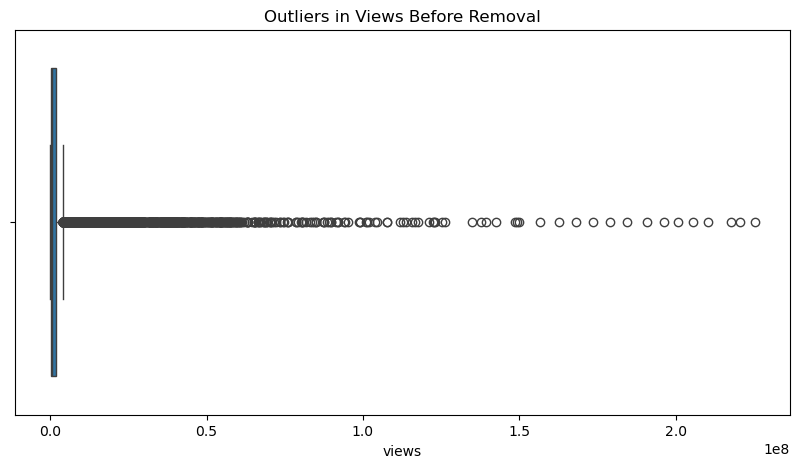

In [19]:
# Before removing outliers
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.boxplot(x=df['views'])
plt.title("Outliers in Views Before Removal")
plt.show()

In [20]:
# Remove extreme outliers based on views
df = df[df['views'] <= df['views'].quantile(0.99)]

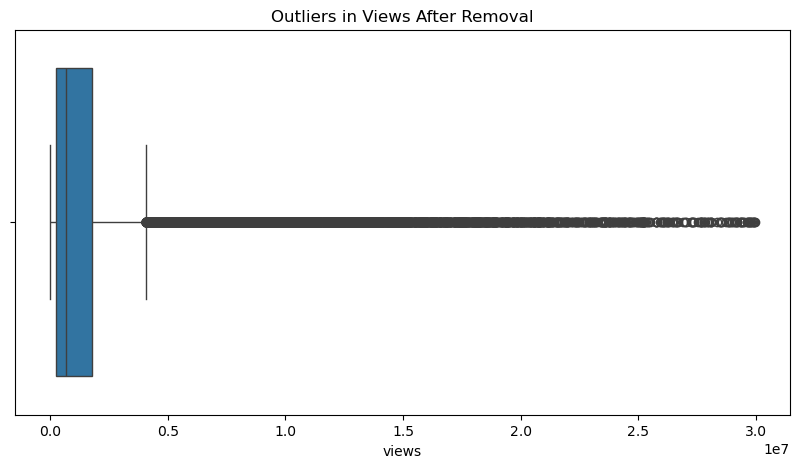

In [21]:
# After removing outliers
plt.figure(figsize=(10,5))
sns.boxplot(x=df['views'])
plt.title("Outliers in Views After Removal")
plt.show()

In [22]:
# Verify data after outlier removal
df[['views', 'likes', 'dislikes', 'comment_count']].describe()

,views,likes,dislikes,comment_count
count,3.992800e+04,3.992800e+04,39928.000000,39928.000000
mean,1.801590e+06,6.039968e+04,2631.460930,6684.492937
std,3.341366e+06,1.392565e+05,10962.024166,19989.509888
min,5.490000e+02,0.000000e+00,0.000000,0.000000
25%,2.435792e+05,5.527750e+03,202.000000,616.000000
50%,6.760620e+05,1.795850e+04,624.000000,1841.000000
75%,1.769102e+06,5.354925e+04,1863.000000,5599.250000
max,2.994356e+07,2.700800e+06,497847.000000,658130.000000


## Final Data Cleaning Summary and Validation

After completing all data cleaning steps, the dataset has been checked for missing values, duplicates, inconsistencies, and extreme outliers.
This final validation ensures that the dataset is clean, reliable, and suitable for further analysis or modeling.

In [23]:
# Final dataset information
df.info()

# Final check for missing values
df.isnull().sum()

# Final dataset shape
df.shape

<class 'pandas.core.frame.DataFrame'>
Index: 39928 entries, 0 to 40948
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   video_id                39928 non-null  object
 1   trending_date           39928 non-null  object
 2   title                   39928 non-null  object
 3   channel_title           39928 non-null  object
 4   category_id             39928 non-null  int64 
 5   publish_time            39928 non-null  object
 6   tags                    39928 non-null  object
 7   views                   39928 non-null  int64 
 8   likes                   39928 non-null  int64 
 9   dislikes                39928 non-null  int64 
 10  comment_count           39928 non-null  int64 
 11  thumbnail_link          39928 non-null  object
 12  comments_disabled       39928 non-null  bool  
 13  ratings_disabled        39928 non-null  bool  
 14  video_error_or_removed  39928 non-null  bool  
 15  descrip

(39928, 16)